In [1]:
#other imports
import os
import numpy as np
import scipy as sp
import pickle
os.chdir('C:/Code/Github/GLM-analysis/')

In [2]:
from DataHandlerDecoding import DataHandlerDecoding as datafun
from Plotter import Plotter as plotterfun
from DecoderAnalyzer import DecoderAnalyzer as analysisdec
from AnalysisManagerEncoding import AnalysisManagerEncoding as analysisenc
from DatasetConfig import DatasetConfig

In [3]:
#initialize class
# decoded_variables= {'sound_category', 'choice', 'photostim', 'outcome','shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome'}
# decoded_variables= {'sound_category','shuffled/sound_category'}#{'choice', 'shuffled/choice'}#{'sound_category','shuffled/sound_category', 'choice', 'shuffled/choice','outcome','shuffled/outcome'}
decoded_variables=  {'sound_category','shuffled/sound_category'}#{'outcome','shuffled/outcome'} #{'sound_category','shuffled/sound_category'}#{'photostim','shuffled/photostim'} #{'photostim','shuffled/photostim'} #,'photostim','shuffled/photostim'}

data_handler = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed
data_handler_pass = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed

In [ ]:
config = DatasetConfig()

info_dir = 'V:/Connie/results/opto_2024/context/mod'
all_datasets, mouse_dates_keys = config.load_from_info(info_dir, data_handler)
datasets, filtered_keys = config.get_datasets_with_variables(decoded_variables)



Unique base variables: {'sound_category'}
Indices to remove: {8, 22}

Filtered datasets (23):
Animal: HA11-1R, Date: 2023-05-05
Animal: HA11-1R, Date: 2023-04-13
Animal: HA2-1L, Date: 2023-04-12
Animal: HA2-1L, Date: 2023-05-05
Animal: HA1-00, Date: 2023-06-29
Animal: HA1-00, Date: 2023-08-28
Animal: HE4-1L1R, Date: 2023-08-21
Animal: HE4-1L1R, Date: 2023-08-24
Animal: HA10-1L, Date: 2023-04-17
Animal: HA10-1L, Date: 2023-04-12
Animal: HA11-1R, Date: 2023-04-07
Animal: HA11-1R, Date: 2023-05-01
Animal: HA11-1R, Date: 2023-05-02
Animal: HA2-1L, Date: 2023-04-28
Animal: HA2-1L, Date: 2023-05-01
Animal: HA1-00, Date: 2023-06-27
Animal: HA1-00, Date: 2023-07-07
Animal: HA1-00, Date: 2023-08-25
Animal: HE4-1L1R, Date: 2023-08-14
Animal: HE4-1L1R, Date: 2023-08-28
Animal: HE4-1L1R, Date: 2023-09-04
Animal: HA10-1L, Date: 2023-03-31
Animal: HE1-00, Date: 2023-05-30


In [ ]:
# LOAD INFO ABOUT DATASETS
info_dir = 'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)

# Indices to remove (example: remove datasets at indices 0 and 2)
#remove_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #testing with all datasets

#UPDATED (WILL NEED TO ADD DATASETS TO THIS LIST) jan 22 2025
#remove_indices = [8,22] #NO CHOICE
remove_indices = [8,22] #NO SOUND
#remove_indices = [2,24] #[2,8,11,22,23,24]#[24] #NO PHOTOSTIM (CONTROL MOUSE)
# remove_indices = [2,7,8,20,21,22] #NO OUTCOME 11

# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]
for dat in datasets:
    print(dat)

('HA11-1R', '2023-05-05', 'V:')
('HA11-1R', '2023-04-13', 'V:')
('HA2-1L', '2023-04-12', 'V:')
('HA2-1L', '2023-05-05', 'V:')
('HA1-00', '2023-06-29', 'V:')
('HA1-00', '2023-08-28', 'W:')
('HE4-1L1R', '2023-08-21', 'W:')
('HE4-1L1R', '2023-08-24', 'W:')
('HA10-1L', '2023-04-17', 'V:')
('HA10-1L', '2023-04-12', 'V:')
('HA11-1R', '2023-04-07', 'V:')
('HA11-1R', '2023-05-01', 'V:')
('HA11-1R', '2023-05-02', 'V:')
('HA2-1L', '2023-04-28', 'V:')
('HA2-1L', '2023-05-01', 'V:')
('HA1-00', '2023-06-27', 'V:')
('HA1-00', '2023-07-07', 'W:')
('HA1-00', '2023-08-25', 'W:')
('HE4-1L1R', '2023-08-14', 'W:')
('HE4-1L1R', '2023-08-28', 'W:')
('HE4-1L1R', '2023-09-04', 'W:')
('HA10-1L', '2023-03-31', 'V:')
('HE1-00', '2023-05-30', 'V:')


In [5]:
#LOAD ACTUAL DATASETS 
save_results = os.path.join(f'V:/Connie/results/glm_decoding/prelim')
os.makedirs(save_results, exist_ok=True)
cat_results = []
cat_results_pass = []

model_type = 'GLM_3nmf_pre'
results_pre,results_pre_all_sb, cat_results, celltype_info = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives means across sc or pop
if 'photostim' in decoded_variables or 'sound_category' in decoded_variables:
    model_type = 'GLM_3nmf_passive'
    results_pass,results_pass_all_sb, cat_results_pass, celltype_info = data_handler_pass.process_multiple_datasets(datasets, model_type,single_balanced=True) 

Processing dataset: HA11-1R_2023-05-05
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/1_1/
decoder_results_shuffled_sound_category.mat
decoder_results_regular_sound_category.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/2_1/
decoder_results_shuffled_sound_category.mat
decoder_results_regular_sound_category.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/3_1/
decoder_results_shuffled_sound_category.mat
decoder_results_regular_sound_category.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/4_1/
decoder_results_shuffled_sound_category.mat
decoder_results_regular_sound_category.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/5_1/
decoder_results_shuffled_sound_category.mat
decoder_results_regular_sound_category.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/6_1/
decoder_results_shuffled_sound_category.mat
decoder_results_regular_sound_category.mat
V:/Connie/Processed

In [6]:
def save_process_multiple_datasets_output(output, filename):
    """
    Save the output of process_multiple_datasets to a file using pickle.
    
    Parameters:
    - output: The output of process_multiple_datasets
    - filename: str, the filename to save the output
    """
    with open(filename, 'wb') as file:
        pickle.dump(output, file)
    print(f"Output saved to {filename}")


def load_all_pickles_from_directory(directory):
    """
    Load all pickled files from a given directory.
    
    Parameters:
    - directory: str, the directory to search for pickled files
    
    Returns:
    - dict: A dictionary where keys are filenames (without .pkl extension) and values are the loaded data
    """
    data_dict = {}
    
    # Iterate over all files in the directory
    for filename in os.listdir(directory):
        if filename.endswith('.pkl'):
            filepath = os.path.join(directory, filename)
            with open(filepath, 'rb') as file:
                data = pickle.load(file)
                # Use the filename without the .pkl extension as the key
                key = os.path.splitext(filename)[0]
                data_dict[key] = data
                print(f"Data loaded from {filename}")
    
    return data_dict

In [7]:
# import pickle
# #save as pickled files so we can load them faster?
# save_process_multiple_datasets_output(results_pre, os.path.join(save_results,'choice,' 'results_pre.pkl'))
# save_process_multiple_datasets_output(results_pre, os.path.join(save_results,'choice,' 'results_pre_all_sb.pkl'))
# save_process_multiple_datasets_output(results_pass, os.path.join(save_results, 'results_pass.pkl'))
# save_process_multiple_datasets_output(results_pass, os.path.join(save_results, 'results_pass_all_sb.pkl'))
#save_process_multiple_datasets_output(cat_results, os.path.join(save_results,'choice,' 'cat_results.pkl'))
# save_process_multiple_datasets_output(cat_results_pass, os.path.join(save_results,'choice,' 'cat_results_pass.pkl'))
# save_process_multiple_datasets_output(celltype_info, os.path.join(save_results,'choice,' 'celltype_info.pkl'))


In [6]:
#Initialize plotting class

# Define colors dictionary
colors_dict = {
    'pyr': (0.37, 0.75, 0.49), 
    'som': (0.17, 0.35, 0.8), 
    'pv': (0.82, 0.04, 0.04)
}

plotter = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results)
#initialize analysis class from encoding bc we are using the same functions
analysisenc = analysisenc(data = None, plotter = plotter)

In [9]:
# for dataset in results_pre_all_sb:
#     print(dataset)
#     print(np.shape(results_pre_all_sb[dataset]['photostim']['sc_cumulative_information_mean']))

# del results_pre_all_sb['HE1-00_2023-05-30']

#np.shape(results_pass_all_sb['HE1-00_2023-05-30']['shuffled/sound_category']['sc_cumulative_information_mean'])
# for dataset in results_pre_all_sb:
#     print(np.shape(cat_results[dataset]['shuffled/sound_category'][2]['sc_cumulative_information']))
# del cat_results['HE4-1L1R_2023-08-21']

In [8]:
# Get shuffled data into frames x neurons x total shuffles across splits (50 * 10 = 500)
print(list(decoded_variables)[0])
shuffled_structure = data_handler.create_shuffled_distribution_structure(decoder_type = list(decoded_variables)[1], metric = 'sc_instantaneous_information')
if 'photostim' in decoded_variables or 'sound_category' in decoded_variables:
    shuffled_structure_pass = data_handler_pass.create_shuffled_distribution_structure(decoder_type = list(decoded_variables)[1], metric = 'sc_instantaneous_information')
  

shuffled/sound_category
HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
Error processing HA2-1L_2023-04-12 on shuffle 1: 'shuffled/sound_category'
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
Error processing HE4-1L1R_2023-08-21 on shuffle 1: 'shuffled/sound_category'
HE4-1L1R_2023-08-24
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-04-07
Error processing HA11-1R_2023-04-07 on shuffle 1: 'shuffled/sound_category'
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
Error processing HE4-1L1R_2023-08-14 on shuffle 1: 'shuffled/sound_category'
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HA10-1L_2023-03-31
HE1-00_2023-05-30
HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-04-07
HA11-1R_2023-05-01
HA11-1R_2023-

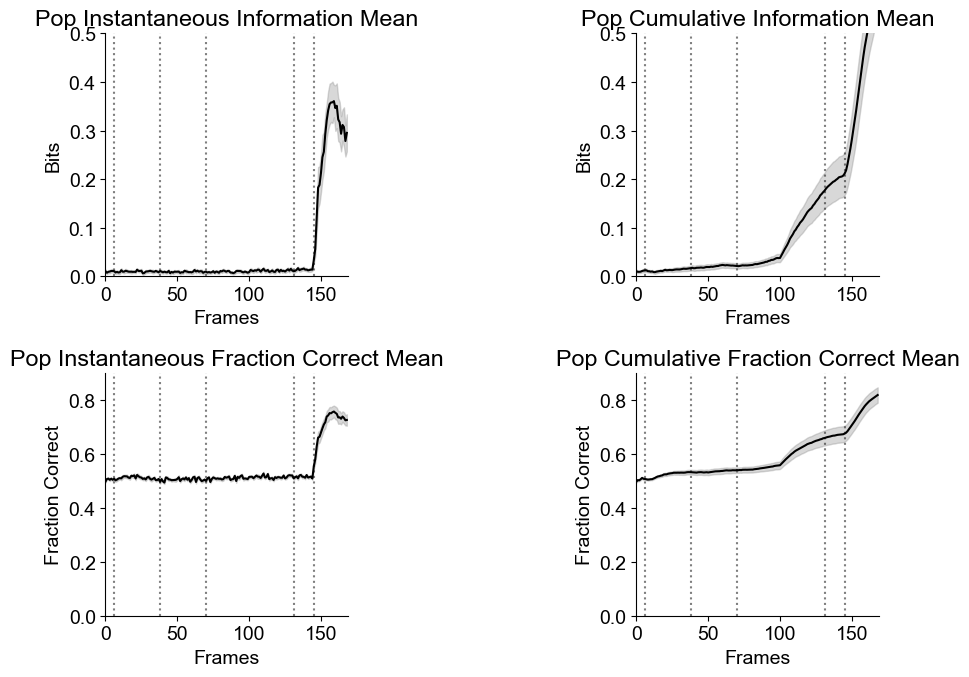

In [50]:
# Plot population decoders across datasets
current_model_type = 'pre'
results_pre_all = results_pre_all_sb
current_decoder_type = list(decoded_variables)[0] #'choice'   
os.makedirs(f'{plotter.save_results}/{current_model_type}/', exist_ok=True)

# Usage example:
plotter.plot_decoding_results(results_pre_all, 
                     decoder_type= current_decoder_type,
                     plot_type='pop', # or sc
                     save_dir= None, #f'{plotter.save_results}/{current_model_type}', #,save_dir = f'{save_results}/{current_decoder_type}_{current_model_type}_pop'
                     xlim = (0,169),
                     ylim = [0.5, 0.5, .9, .9]) #define y limits for each subplot

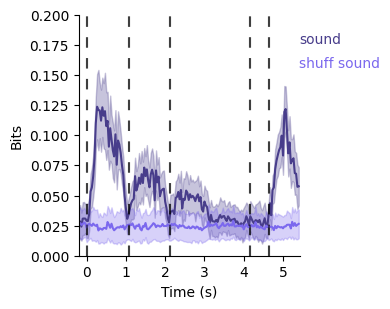

 (array([0.02896266, 0.02884253, 0.03482872, 0.05330849, 0.05672471,
       0.06578719, 0.08059214, 0.11009946, 0.12375777, 0.1209593 ,
       0.12069554, 0.11218684, 0.12329252, 0.11623586, 0.12011076,
       0.10766355, 0.1119699 , 0.09056692, 0.10593564, 0.09673646,
       0.0875541 , 0.08250017, 0.1008444 , 0.07555993, 0.09569402,
       0.09234921, 0.0854808 , 0.07508137, 0.06708754]), array([0.02338802, 0.02560948, 0.02648309, 0.02576295, 0.0247787 ,
       0.02666375, 0.02544123, 0.02482934, 0.02577374, 0.02100063,
       0.02279141, 0.02219482, 0.02163357, 0.02298969, 0.02306496,
       0.02234663, 0.02800262, 0.02582228, 0.02322183, 0.02658867,
       0.02297075, 0.02112132, 0.02217957, 0.02328147, 0.02370036,
       0.02330823, 0.02450876, 0.02361016, 0.02511587])) 
Bonferroni corrected alpha threshold: 0.05000


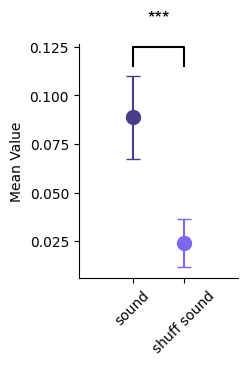

([3.725290298461914e-09], [3.725290298461914e-09])

In [9]:
# List of mean_results and corresponding decoder types
mean_results_list = [results_pre_all_sb, results_pre_all_sb]# [results_pre_all_sb, results_pre_all_sb]#[results_pre_all_sb, results_pre_all_sb]#[results_pre_all_sb, results_pass_all_sb]
decoder_types = ['sound_category','shuffled/sound_category'] #['sound_category','sound_category'] #['sound_category','sound_category'] #['choice','shuffled/choice'] ##['sound_category','sound_category'] #['photostim','photostim'] #['outcome', 'shuffled/outcome']

# Plot population decoders across datasets
current_model_type = 'bothshuffled'#'pre' or passive
data_type = 'information'#'fraction_correct' #'information'#'fraction_correct' #'information'# 'fraction_correct' or 'information'
if data_type == 'information':
    ylabel = 'Bits'
    ylimss = (0.0,.2)
else:
    ylabel = '% Accuracy'
    ylimss = (0.45,.8)
current_decoder_type = decoder_types[0]
save_dir_contexts = f'{plotter.save_results}/{current_model_type}_instantaneous_{data_type}_{current_decoder_type}'
# results_pre_all = results_pre_all_sb 

labels = ['sound','shuff sound'] #['choice','shuff choice'] #['Active', 'Passive']
colors_used = ['darkslateblue','mediumslateblue']#['mediumvioletred','hotpink']#['saddlebrown','darkorange'] #['steelblue','lightskyblue'] #['mediumvioletred','hotpink']##['saddlebrown','darkorange'] # ['mediumvioletred','hotpink']#['steelblue','lightskyblue'] #['saddlebrown','darkorange'] #['darkslateblue','mediumslateblue'] #colors for the bar plot     
frames_used = np.arange(6,35) #frames to plot in the bar/scatter plot (7,22)
os.makedirs(save_dir_contexts , exist_ok=True)


# Plot the selected metric and get concatenated means and SEMs
concatenated_means, concatenated_sems = plotter.plot_selected_metric_with_sem(mean_results_list, decoder_types, 
                                                                      metric=f'pop_instantaneous_{data_type}_mean', 
                                                                      title= None, 
                                                                      xlabel='Seconds', 
                                                                      ylabel= ylabel, #'SC Metric 1 Value',
                                                                      ylim = ylimss, #(0.01,.03)
                                                                      xlim = (0,169), #in terms of frames (30 frames = 1 second)
                                                                    save_dir=None,#save_dir_contexts,
                                                                    labels = labels,
                                                                    colors = colors_used)


# create bar or scatter plot of mean values at specific range of values
plotter.simple_plot_wrapper(labels, concatenated_means, concatenated_sems,plot_type = 'scatter', colors= colors_used, frames = frames_used, ylabel = 'Mean Value', save_dir = None)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_dataset_metric_with_sem( mean_results_list, dataset_key, decoder_types, metric, 
                               start_frame=0, xlim=None, ylim=None, title=None, 
                               xlabel='Frames', ylabel=None, colors=['blue', 'red'], 
                               labels=['Active','Passive'], save_dir=None):
    """Plot metric for specific dataset across conditions."""
    plt.figure(figsize=(4,3))
    
    for idx, (mean_results, decoder_type) in enumerate(zip(mean_results_list, decoder_types)):
        # Get data for specific dataset
        if dataset_key not in mean_results:
            print(f"Dataset {dataset_key} not found in results")
            continue
            
        # Get event frames
        event_frames = mean_results[dataset_key][decoder_type]['event_frame_mean']
        
        # Determine metric type
        plot_type = 'sc' if 'sc' in metric else 'pop'
        
        # Get data for this dataset
        data = mean_results[dataset_key][decoder_type][metric]
        
        # Calculate mean and SEM
        if plot_type == 'sc':
            mean_trace = np.mean(data, axis=1)
            sem_trace = sp.stats.sem(data, axis=1)
        else:
            mean_trace = data
        
        
        # Create x-axis
        x = np.arange(len(mean_trace))
        
        # Plot
        plt.plot(x[start_frame:], mean_trace[start_frame:], 
                color=colors[idx], label=labels[idx])
        if plot_type == 'sc':
            plt.fill_between(x[start_frame:], 
                            mean_trace[start_frame:] - sem_trace[start_frame:],
                            mean_trace[start_frame:] + sem_trace[start_frame:],
                            alpha=0.2, color=colors[idx])
        
        # Add event frame line
        plt.axvline(x=event_frames[0], color='k', linestyle='--', alpha=0.5)
    
    # Customize plot
    if title is None:
        title = f"{dataset_key} - {metric}"
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel if ylabel else metric)
    plt.legend(frameon=False)

    xticks_in, xticks_lab = plotter.x_axis_sec_aligned(event_frames[0], len(mean_trace), interval=1, frame_rate=30)
    plt.xticks(ticks=xticks_in, labels=xticks_lab)
    plt.xlabel('Time (s)')
    
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    
    if save_dir:
        plt.savefig(os.path.join(save_dir, f"{dataset_key}_{metric}.png"))
    
    plt.show()

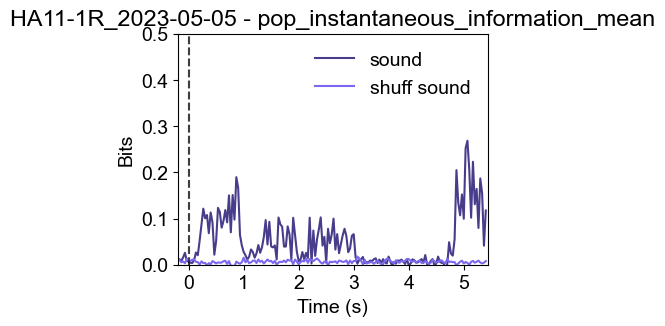

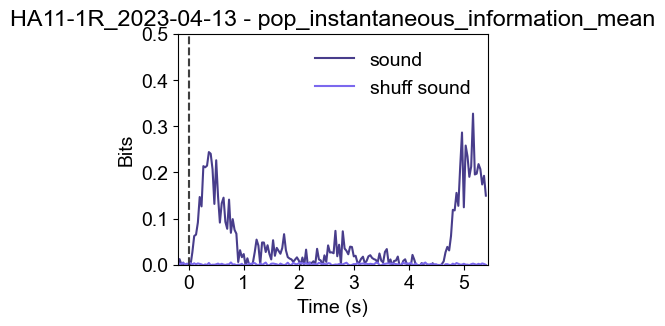

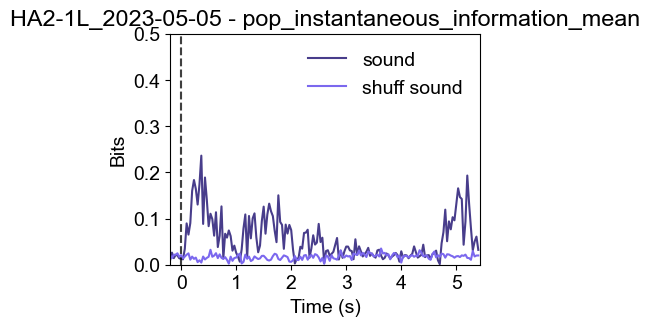

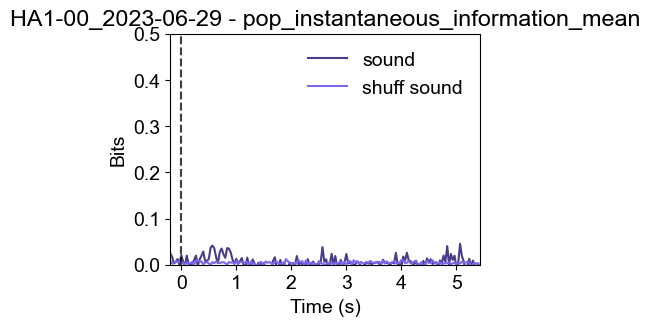

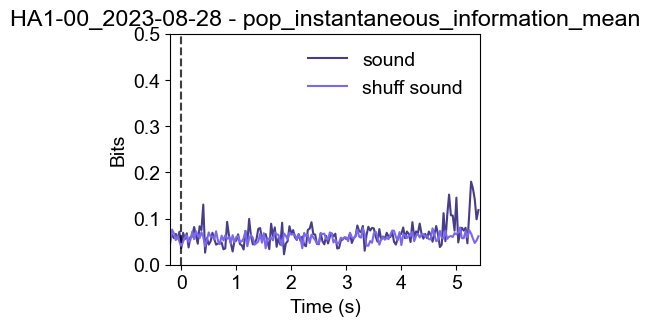

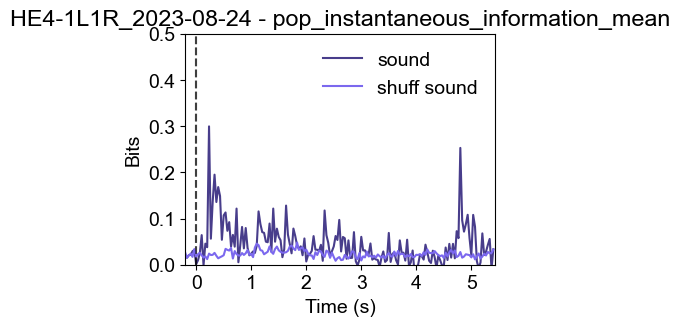

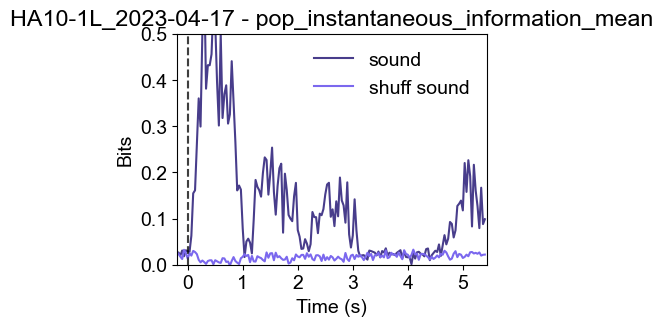

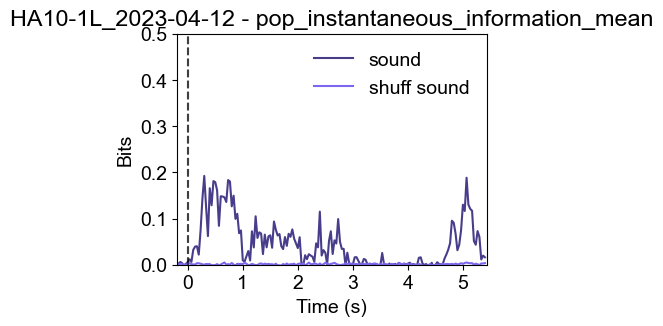

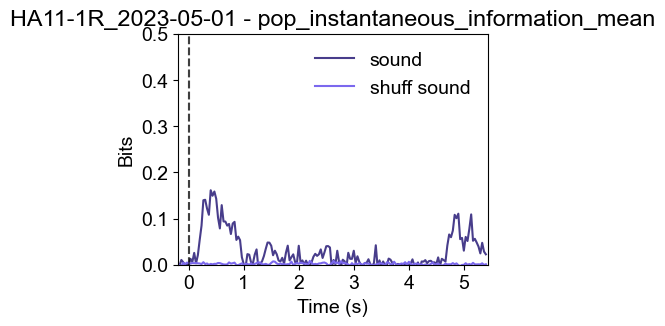

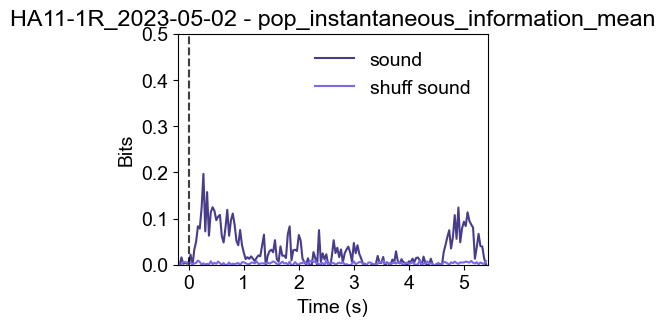

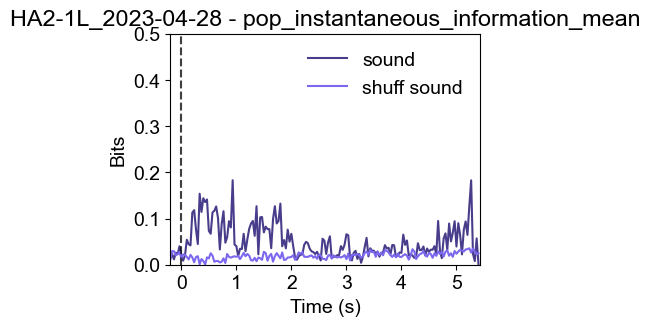

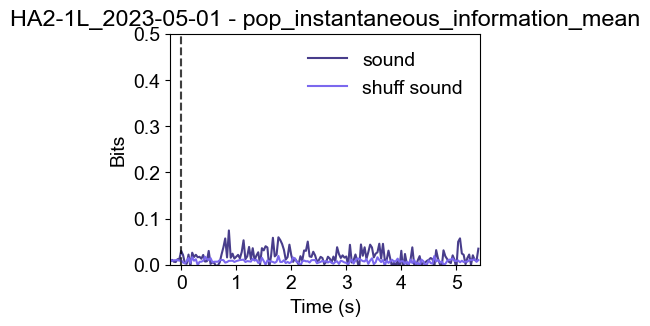

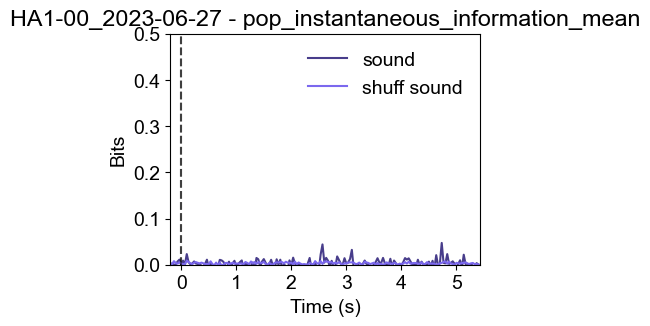

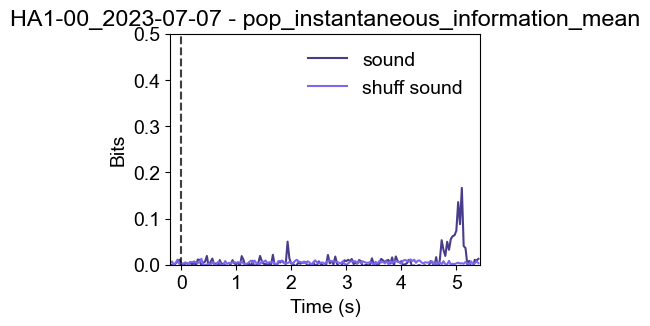

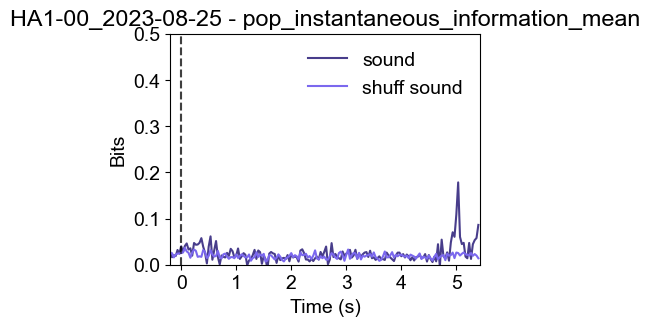

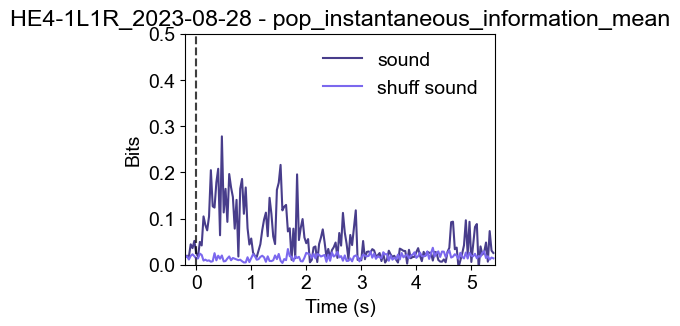

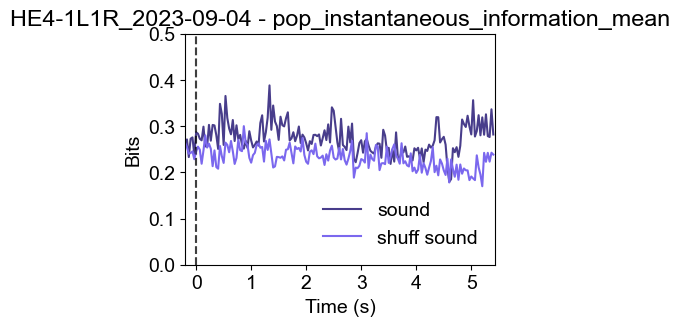

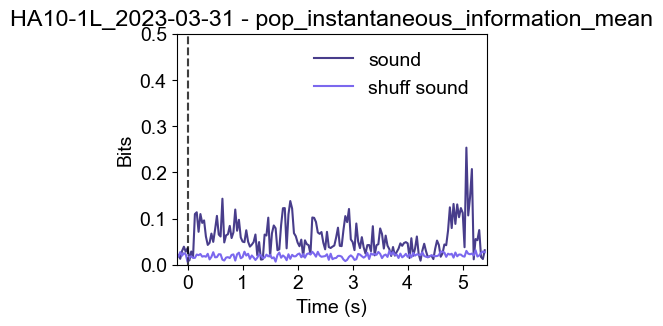

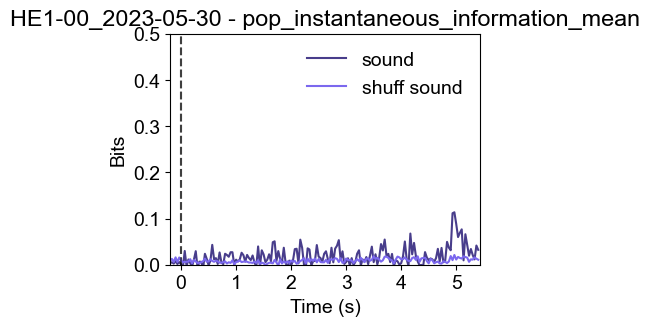

In [12]:
# os.mkdir('V:/Connie/results/glm_decoding/outcome_decoding')
for dataset_key in results_pre_all_sb:
  # dataset_key = list(results_pre_all_sb.keys())[0]
  plotter.plot_dataset_metric_with_sem(mean_results_list,dataset_key, decoder_types,  
                            title= None, 
                            metric = f'pop_instantaneous_information_mean',
                            start_frame=0,
                            xlabel='Seconds', 
                            ylabel= ylabel, #'SC Metric 1 Value',
                            ylim = (0.0,.5), #ylimss, #(0.01,.03)
                            xlim = (0,169), #in terms of frames (30 frames = 1 second)
                          save_dir='V:\Connie/results\glm_decoding\sound_decoding', #,#save_dir_contexts,
                          labels = labels,
                          colors = colors_used)       

In [13]:
  # dataset_key = list(results_pre_all_sb.keys())[0]
plot_dataset_metric_with_sem(mean_results_list,'HE4-1L1R_2023-09-04', decoder_types,  
                        title= None, 
                        metric = f'pop_instantaneous_fraction_correct_mean',
                        start_frame=0,
                        xlabel='Seconds', 
                        ylabel= ylabel, #'SC Metric 1 Value',
                        ylim = (0.45, .7), #(0.01,.03)
                        xlim = (0,100), #in terms of frames (30 frames = 1 second)
                        save_dir='V:\Connie/results\glm_decoding\sound_decoding', #,#save_dir_contexts,
                        labels = labels,
                        colors = colors_used)   

NameError: name 'plot_dataset_metric_with_sem' is not defined

In [14]:
# Create an instance of AnalysisManager, passing in the plotter module
analysis_dec = analysisdec(celltype_info)

In [15]:
def analyze_peaks_by_celltype_test( mean_results_all, shuffled_structure,method ='range_threshold', decoder_type='sound_category', start_frame=14, end_frame=None, significance_percentile=95, threshold =None):
    """Analyze peak responses separated by cell type and flag significantly informative neurons.
        Parameters:
    - data: dict, data for different cell types
    - method: str, method to calculate significance ('shuffled_peak', 'threshold_peak', 'range_threshold')
    - threshold: float, threshold value for 'threshold_peak' and 'range_threshold' methods
    - range_start: int, start of the range for 'range_threshold' method
    - range_end: int, end of the range for 'range_threshold' method
    
    Returns:
    - results: dict, results of the analysis
    """
    peaks_by_celltype = {
        dataset: {
            celltype: {
                'sc': {},
                'pop': {}
            } for celltype in mean_results_all[dataset]['neuron_groups']
        } for dataset in mean_results_all
    }
    # Single cell metrics
    sc_metrics = ['sc_instantaneous_information_mean','sc_cumulative_information_mean','sc_instantaneous_fraction_correct_mean','sc_cumulative_fraction_correct_mean']
    
    for dataset in mean_results_all:
        celltype_array = mean_results_all[dataset]['celltype_array']
        # Get indices for each cell type
        celltype_indices = {
            'pyr': np.where(celltype_array == 0)[0],
            'som': np.where(celltype_array == 1)[0],
            'pv': np.where(celltype_array == 2)[0]
        }
        # Process single cell metrics
        for metric in sc_metrics:
            if metric in mean_results_all[dataset][decoder_type]:
                data = mean_results_all[dataset][decoder_type][metric]
                if end_frame is None:
                    end_frame = len(data)
                # Retrieve shuffled data for comparison
                shuffled_data = shuffled_structure [dataset] #mean_results_all[dataset][f'shuffled/{decoder_type}'][metric]
                for celltype, indices in celltype_indices.items():
                    peaks = []
                    peak_frames = []
                    significant_neurons = []  # Track significant neurons for this metric
                    for idx in indices:
                        neuron_data = data[start_frame:end_frame, idx]
                        peak_val = np.max(neuron_data)
                        peak_frame = np.argmax(neuron_data) + start_frame
                        
                        peaks.append(peak_val)
                        peak_frames.append(peak_frame)
                        # Flag the neuron as significant if the peak value exceeds the 95th percentile
                        if method == 'shuffled_peak':#threshold is None:
                            # Compute the peak value for the shuffled distribution
                            shuffled_peak = shuffled_data[peak_frame, idx, :]
                            # Compute the 95th percentile of the shuffled peak values
                            shuffled_95th_percentile = np.percentile(shuffled_peak, significance_percentile)
                            is_significant = peak_val > shuffled_95th_percentile
                            significant_neurons.append(is_significant)
                        elif method == 'range_threshold':
                            print('range_threshold')
                            is_significant = np.any(neuron_data > threshold)
                            significant_neurons.append(is_significant)
                        elif method == 'threshold_peak':
                            print('threshold_peak')
                            is_significant = peak_val > threshold
                            significant_neurons.append(is_significant)
                                
                                

In [74]:
dataset_to_test = ('HE1-00_2023-05-30','HA1-00_2023-08-28') #('HA1-00_2023-08-28', 'HA1-00_2023-08-25','HA10-1L_2023-04-17') #('HA10-1L_2023-03-31') #
results_to_test = {dataset: results_pre_all_sb[dataset] for dataset in dataset_to_test}

Cell type: pyr, Number of significant neurons: 1424
Cell type: som, Number of significant neurons: 92
Cell type: pv, Number of significant neurons: 238
Cell type: all, Number of significant neurons: 1754


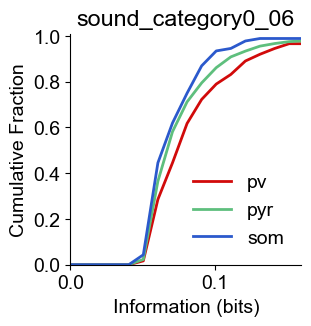

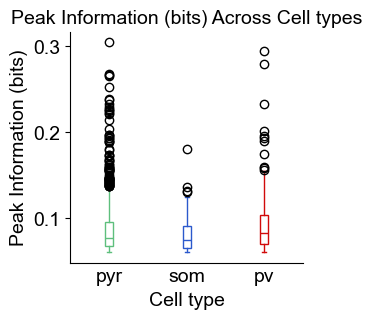

In [17]:
#DECIDE WHETHER OR NOT TO USE END FRAME
current_model_type = 'both'
current_decoder_type = 'sound_category' #'choice' #'sound_category' #'photostim' #'outcome'
results_pre_all = results_pre_all_sb #results_to_test #results_pre_all_sb
start_frame = 14 #14 before this there is artifact
end_frame = 100 #100 for sound/photostim
threshold =  0.06 #use threshold OR percentile to decide signficant neurons
method = 'range_threshold'# 'shuffled_peak', 'threshold_peak', 'range_threshold', 'combined'
metric_to_plot = 'sc_instantaneous_information_mean'

# Replace dot with underscore in threshold for directory name
threshold_str = str(threshold).replace('.', '_')
save_path = f'{plotter.save_results}/{current_model_type}{start_frame}{current_decoder_type}/'
os.makedirs(save_path , exist_ok=True)

# Analyze peaks by cell type
peaks_by_celltype = []
peaks_by_celltype = analysis_dec.analyze_peaks_by_celltype( results_pre_all,shuffled_structure, method = method,
                                                            decoder_type=current_decoder_type, start_frame=start_frame , end_frame = end_frame,
                                                            significance_percentile = 5, threshold = threshold) #, end_frame = 100

#PLOT DISTRIBUTIONS OF SIGINIFICANT NEURONS!

cdf_data, cell_labels = analysis_dec.format_peaks_for_cdf(peaks_by_celltype,metric = metric_to_plot, significant_only=True)
all_peaks, neuron_groups = analysis_dec.format_peaks_for_boxplot(peaks_by_celltype, metric = metric_to_plot, significant_only=True)

#cdf
if "shuffled" in current_decoder_type:
    current_decoder_type = current_decoder_type.replace('/', '_') #replace / with _
plotter.plot_cdf_coupling_index(np.array(cdf_data['all']['peaks']),
                                cell_labels,
                                colors = plotter.celltypecolors,
                                title=f'{current_decoder_type}{threshold_str}',
                                xlabel = 'Information (bits)',
                                xval=.15,
                                xint=0.1,
                                save_path=f'{save_path}{current_decoder_type}_cdf_thr{threshold_str}.svg')

#make boxplot!
plotter.box_plot(
    data=all_peaks,
    neuron_groups=neuron_groups,
    colors=plotter.celltypecolors,
    measure_string='Peak Information (bits)',
    save_path=f'{save_path}{current_decoder_type}_box_plot_thr{threshold_str}.png'
)

#heatmap across datasets
#plotter.plot_decoding_heatmap_datasets(results_pre_all, decoder_type= current_decoder_type, metric = 'pop_instantaneous_information_mean')

# PRINT OUT # OF SIGNIFICANT NEURONS PER CELL TYPE
# Assuming cdf_data is a dictionary with cell types as keys and peaks as values
for cell_type, data in cdf_data.items():
    if 'peaks' in data:
        num_significant_neurons = len(np.array(data['peaks']))
        print(f'Cell type: {cell_type}, Number of significant neurons: {num_significant_neurons}')


In [ ]:
import matplotlib.pyplot as plt 
plt.plot(np.mean(shuffled_structure_pass['HA10-1L_2023-03-31'][0:100,:,:], axis = 1))
plt.axvline(x = 14, color = 'r')


NameError: name 'shuffled_structure_pass' is not defined

In [ ]:
example_neuron =  0
metric_to_plot = 'sc_instantaneous_information'
mt = 'pre' # or pre

shuffled_structure = data_handler_pass.create_shuffled_distribution_structure(decoder_type = 'sound_category', metric = metric_to_plot)
shuffled_dist = shuffled_structure['HA1-00_2023-08-25'][0:100,example_neuron,:] #becomes frames x shuffles
thr = np.percentile(shuffled_dist, 95, axis=1) # axis = 1 gives 86 values (frames?), axis = 0 gives 500 values (shuffles?)
print(np.mean(thr))
plt.plot(np.mean(shuffled_dist, axis = 1), color = 'gray')
plt.plot(results_pass_all_sb['HA1-00_2023-08-25']['sound_category'][f'{metric_to_plot}_mean'][0:100,example_neuron]) #frames x cells
plt.axvline(x = 14, color = 'r')

HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-04-07
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HA10-1L_2023-03-31
HE1-00_2023-05-30
0.1008772196965862


NameError: name 'plt' is not defined

In [ ]:
np.where((results_pass_all_sb['HA10-1L_2023-03-31']['sound_category']['sc_instantaneous_information_mean'][14:100,:]>0.08).sum(axis=0)) #number of significant neurons

(array([  2,   9,  16,  21,  34,  68, 127, 254, 270, 276, 282, 319, 328,
        346, 358, 382], dtype=int64),)

In [ ]:
celltype_ex = 'som'
print(np.where(peaks_by_celltype['HA11-1R_2023-05-05'][f'{celltype_ex}']['sc']['sc_instantaneous_information_mean']['significant_neurons']))
print((peaks_by_celltype['HA11-1R_2023-05-05'][f'{celltype_ex}']['sc']['sc_instantaneous_information_mean']['peak_values'][np.where(peaks_by_celltype['HA11-1R_2023-05-05'][f'{celltype_ex}']['sc']['sc_instantaneous_information_mean']['significant_neurons'])]))   

(array([4], dtype=int64),)
[0.06710303]


In [ ]:
analysis_dec.metrics

{'sc': ['sc_instantaneous_information_mean',
  'sc_cumulative_information_mean',
  'sc_instantaneous_fraction_correct_mean',
  'sc_cumulative_fraction_correct_mean'],
 'pop': ['pop_instantaneous_information_mean',
  'pop_cumulative_information_mean',
  'pop_instantaneous_fraction_correct_mean',
  'pop_cumulative_fraction_correct_mean']}

In [41]:
def visualize_single_neuron_analysis(results_dict,shuffled_structure , plotter, analyzer, decoder_type='sound_category', start_frame=14, end_frame=None, metric = 'sc_instantaneous_information_mean', significance_percentile = 95, threshold = None,method = 'shuffled_peaks', save_path=None):
    """Orchestrate single neuron analysis and visualization."""

    significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons(results_dict,shuffled_structure,method, decoder_type, start_frame, end_frame,metric ,significance_percentile, threshold = threshold)
    
    #using threshold to get significant neurons? threshold_value = 0.06
    # if threshold is not None:
    #     significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons_by_threshold(results_dict, decoder_type, start_frame, end_frame,metric,threshold)
    
    # Extract significant neurons for each dataset
    significant_neurons = {dataset: np.concatenate([significant_neurons_data[dataset][celltype] for celltype in significant_neurons_data[dataset]]) 
                           for dataset in significant_neurons_data}
    
    # Plot the heatmap, only using significant neurons if they exist
    #plotter.plot_neuron_performance_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons) #separated by datasets

    plotter.plot_significant_neurons_distribution(significance_struc,save_path=f'{save_path}_hist.svg') 

    plotter.plot_time_course_by_cell_type(results_dict, decoder_type, start_frame = 0, end_frame = end_frame, metric = metric)

    plotter.plot_summary_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons,save_path=f'{save_path}_heatmap.svg') #combined across datasets

    plotter.plot_significant_neuron_percentages_by_celltype(significant_neurons, celltype_info,  save_path=f'{save_path}.png')

    return significant_neurons_data, significance_struc, significant_neurons

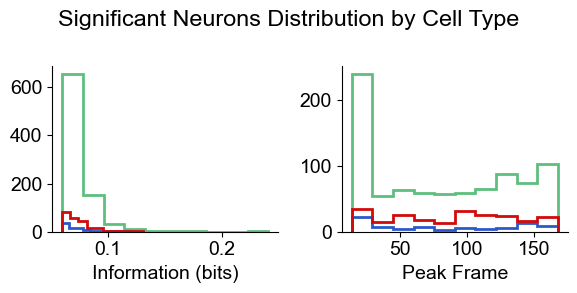

<Figure size 640x480 with 0 Axes>

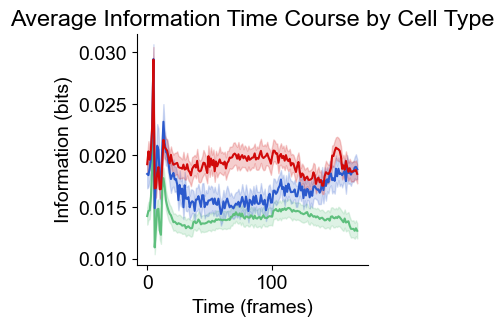

Sig neurons total 1077


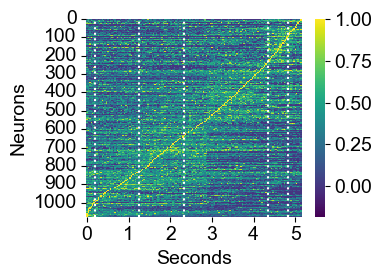

Total significant neurons!! 8


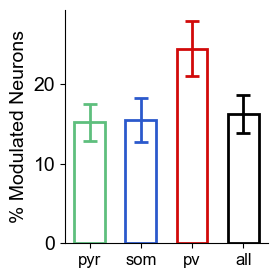

Significantly Modulated Neurons (% ± SEM):
pyr: 15.16 ± 2.34%
som: 15.46 ± 2.75%
pv: 24.42 ± 3.45%
all: 16.24 ± 2.39%


In [42]:
# Call the visualization function
threshold = 0.06
current_decoder_type = 'photostim' #'shuffled/photostim' #'shuffled/outcome'
significant_neurons_data, sig_struct, sig_neurons = visualize_single_neuron_analysis(
    results_dict=results_pre_all_sb,
    shuffled_structure = shuffled_structure,
    method = 'range_threshold', #threshold_peak', 'range_threshold'
    plotter=plotter,
    analyzer =analysis_dec,
    decoder_type = current_decoder_type,  # Or your preferred decoder type
    start_frame = 14,#14                 # Specify start frame
    end_frame = 169,  #100                  # Specify end frame if needed, else None
    metric = 'sc_instantaneous_information_mean', #choose sc metric to look at
    significance_percentile = 95,         #used to determine significant cells
    threshold = threshold ,                   #None or 0.06 (from Runyan 2017)
    save_path= None #f'{save_path}{current_decoder_type}_sig_cel_thr{str(threshold)}'
)

# # Save significant neurons data to a .mat file
# mat_file_path = os.path.join(save_path, f'significant_neurons_data_none.mat')
# sp.io.savemat(mat_file_path, significant_neurons_data)


In [ ]:
print(significant_neurons_data['HA11-1R_2023-05-05']['pyr'])
sig_neurons['HA11-1R_2023-05-05']

KeyError: 'HA11-1R_2023-05-05'

In [ ]:
# Function to sanitize field names for MATLAB
def sanitize_field_name(name):
    return ''.join(['_' if not c.isalnum() and c != '_' else c for c in name])

# Prepare data for saving
matlab_data = {}
for dataset, celltypes in significant_neurons_data.items():
    print(dataset)
    sanitized_dataset = sanitize_field_name(dataset)
    matlab_data[sanitized_dataset] = {}
    for celltype, indices in celltypes.items():
        sanitized_celltype = sanitize_field_name(celltype)
        
        if indices is None:
            peaks = [peaks_by_celltype[dataset][celltype]['sc']['sc_instantaneous_information_mean']['peak_values'][index] for index in indices]
            # Add one to each index for MATLAB indexing
            indices = [index + 1 for index in indices]
            matlab_data[sanitized_dataset][sanitized_celltype] = {
                'indices': indices,
                'peaks': peaks
            }
# # Prepare data for saving
# matlab_data = {}
# for dataset, celltypes in significant_neurons_data.items():
#     sanitized_dataset = sanitize_field_name(dataset)
#     matlab_data[sanitized_dataset] = {}
#     for celltype, data in celltypes.items():
#         sanitized_celltype = sanitize_field_name(celltype)
#         matlab_data[sanitized_dataset][sanitized_celltype] = [index + 1 for index in indices]  # Save indices of significant neurons 

# Save significant neurons data to a .mat file
mat_file_path = os.path.join(save_path, 'significant_neurons_data.mat')
sp.io.savemat(mat_file_path, matlab_data)
print(f'Significant neurons data saved to {mat_file_path}')

pyr
som
pv
all
Significant neurons data saved to V:/Connie/results/glm_decoding/prelim/test14sound_category/significant_neurons_data.mat


In [ ]:
# Function to sanitize field names for MATLAB
def sanitize_field_name(name):
    return ''.join(['_' if not c.isalnum() and c != '_' else c for c in name])
# Print the number of significant neurons per cell type and prepare data for saving
significant_neurons_data = {}
for cell_type, data in cdf_data.items():
    if 'peaks' in data:
        num_significant_neurons = len(np.array(data['peaks']))
        print(f'Cell type: {cell_type}, Number of significant neurons: {num_significant_neurons}')
        sanitized_cell_type = sanitize_field_name(cell_type)
        significant_neurons_data[sanitized_cell_type] = {
            'num_significant_neurons': num_significant_neurons,
            'peaks': np.array(data['peaks'])
        }
        print(significant_neurons_data[sanitized_cell_type]['peaks'])

mat_file_path = os.path.join(save_path, 'significant_neurons_data.mat')
sp.io.savemat(mat_file_path, significant_neurons_data)

Cell type: pyr, Number of significant neurons: 521
[0.06093128 0.06288881 0.0602526  0.06305552 0.06261113 0.06077094
 0.07970873 0.07410653 0.06040351 0.10620771 0.10361535 0.0639753
 0.09420181 0.07870833 0.09098404 0.06936493 0.07426267 0.09156709
 0.0780108  0.06940708 0.07359389 0.0628773  0.06111851 0.06154277
 0.08977398 0.24531104 0.10648276 0.0968074  0.0612636  0.08091833
 0.06429535 0.1909286  0.06744243 0.06720493 0.07376014 0.06353274
 0.07911372 0.06161994 0.07491103 0.06001709 0.06331738 0.06409033
 0.06304625 0.11242805 0.08927624 0.06207144 0.06245788 0.06312303
 0.06979827 0.0762244  0.27840908 0.34775523 0.10144604 0.07176455
 0.06750405 0.06289369 0.06267357 0.08986289 0.0835114  0.12695251
 0.07013271 0.12331507 0.06276232 0.06318782 0.07229682 0.14554729
 0.08805272 0.08702839 0.16766645 0.06894762 0.09499151 0.07068461
 0.06996251 0.06081113 0.06187135 0.06800253 0.06201456 0.06705307
 0.06626261 0.13169007 0.0766899  0.22183663 0.11579995 0.14277114
 0.07487704 